In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex02_load_spiideo', 'segmentation_model': 'lightning_logs/version_13/checkpoints/epoch=17-step=288.ckpt', 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'width': 640, 'height': 360}, 'spiideo_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs
from models.field_registration import Segmentation

spiideo_args = SpiideoDatasetArgs(**config['spiideo_dataset'])
spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

ds = spiideo_data_module.dataset('mini')
print(f'Dataset with {len(ds)} images.')

Dataset with 7 images.


### Distortion

In [34]:
width, height = config['spiideo_dataset']['width'], config['spiideo_dataset']['height']
img, metadata, annotations, *_ = ds[0]
metadata.model_dump()

{'id': 0,
 'file_name': '000000.jpg',
 'width': 3840,
 'height': 2160,
 'camera_matrix': array([[-4.69292492e-01,  8.64371300e-01,  1.80628926e-01,
         -3.16473637e+01],
        [ 3.80434364e-01,  1.33105367e-02,  9.24712121e-01,
          6.22067308e+00],
        [-7.96890318e-01, -5.02677917e-01,  3.35083097e-01,
         -4.65564346e+01]]),
 'dist_poly': array([ 3.66892964e-02, -1.81167156e-01,  2.68177211e-01,  3.68174240e-02,
        -4.07823682e-01,  2.50910759e-01, -1.18769035e-01,  7.68861055e-01,
        -7.07547879e-04]),
 'undist_poly': array([ 3.73205503e-12, -1.11320510e-11,  1.27131109e-11, -6.65507883e-12,
         1.03982794e+00, -5.04541695e-01,  2.34189317e-01,  1.30272126e+00,
         8.98241764e-04])}

In [4]:
dist_poly = metadata.dist_poly
undist_poly = metadata.undist_poly
undist_poly

array([ 3.73205503e-12, -1.11320510e-11,  1.27131109e-11, -6.65507883e-12,
        1.03982794e+00, -5.04541695e-01,  2.34189317e-01,  1.30272126e+00,
        8.98241764e-04])

In [5]:
x0, y0 = np.meshgrid(
    np.linspace(0, width, width),
    np.linspace(0, height, height)
)

u0, v0 = (x0 - width / 2) / width, (y0 - height / 2) / width

r0 = np.sqrt(np.square(u0) + np.square(v0))
theta = np.atan2(v0, u0)

r1 = np.polyval(dist_poly, np.atan(r0))
u1, v1 = r1 * np.cos(theta), r1 * np.sin(theta)
x1, y1 = width * u1 + width / 2, width * v1 + height / 2

r2 = np.tan(np.polyval(undist_poly, r1))
u2, v2 = r2 * np.cos(theta), r2 * np.sin(theta)
x2, y2 = width * u2 + width / 2, width * v2 + height / 2

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_66178/1486517475.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


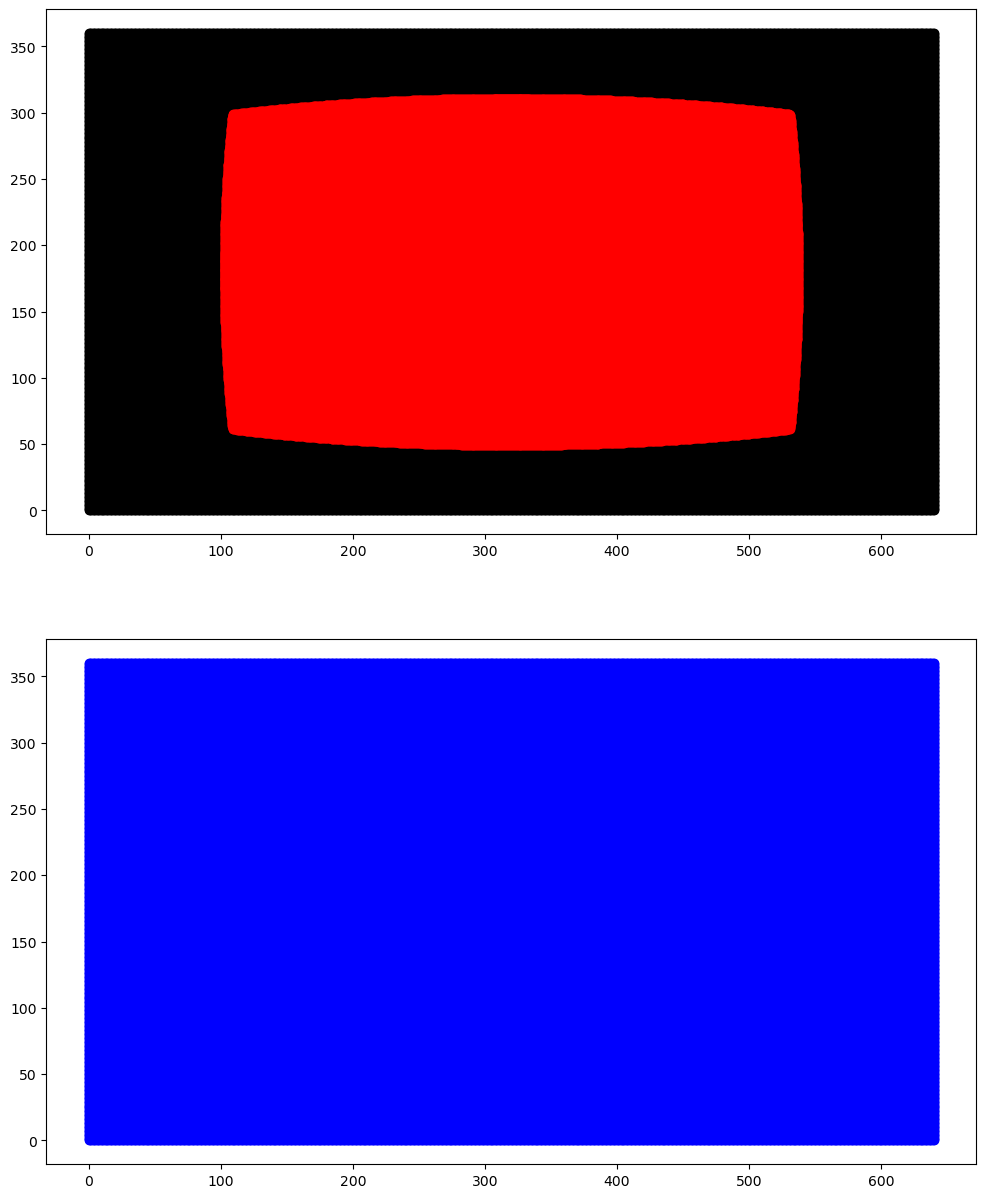

In [6]:
fig, ax = plt.subplots(nrows=2, figsize=(12, 15))
ax[0].scatter(x0, y0, c='black')
ax[0].scatter(x1, y1, c='red')
ax[1].scatter(x1, y1, c='black')
ax[1].scatter(x2, y2, c='blue')
fig.show()

In [7]:
img = ds[0][0]
undist_img = cv2.remap(img, x1.astype('float32'), y1.astype('float32'), interpolation=cv2.INTER_LINEAR)
print(f'Distorted: {img.shape}')
print(f'Undistorted: {undist_img.shape}')

Distorted: (360, 640, 3)
Undistorted: (360, 640, 3)


In [8]:
seg_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
seg_img_2 = cv2.cvtColor(undist_img, cv2.COLOR_RGB2GRAY)

seg_img = torch.Tensor(seg_img).view(1, 1, 360, 640)
seg_img_2 = torch.Tensor(seg_img_2).view(1, 1, 360, 640)

with torch.no_grad():
    segmentation_model = Segmentation.load_from_checkpoint(config['segmentation_model']).to('cpu').eval()
    seg_img = segmentation_model(seg_img).detach()[0][0]
    seg_img_2 = segmentation_model(seg_img_2).detach()[0][0]

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Using cache found in /Users/sam/

In [9]:
undist_seg_img = cv2.remap((seg_img * 255).numpy().astype('uint8'), x1.astype('float32'), y1.astype('float32'), interpolation=cv2.INTER_LINEAR)

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_66178/4025023095.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


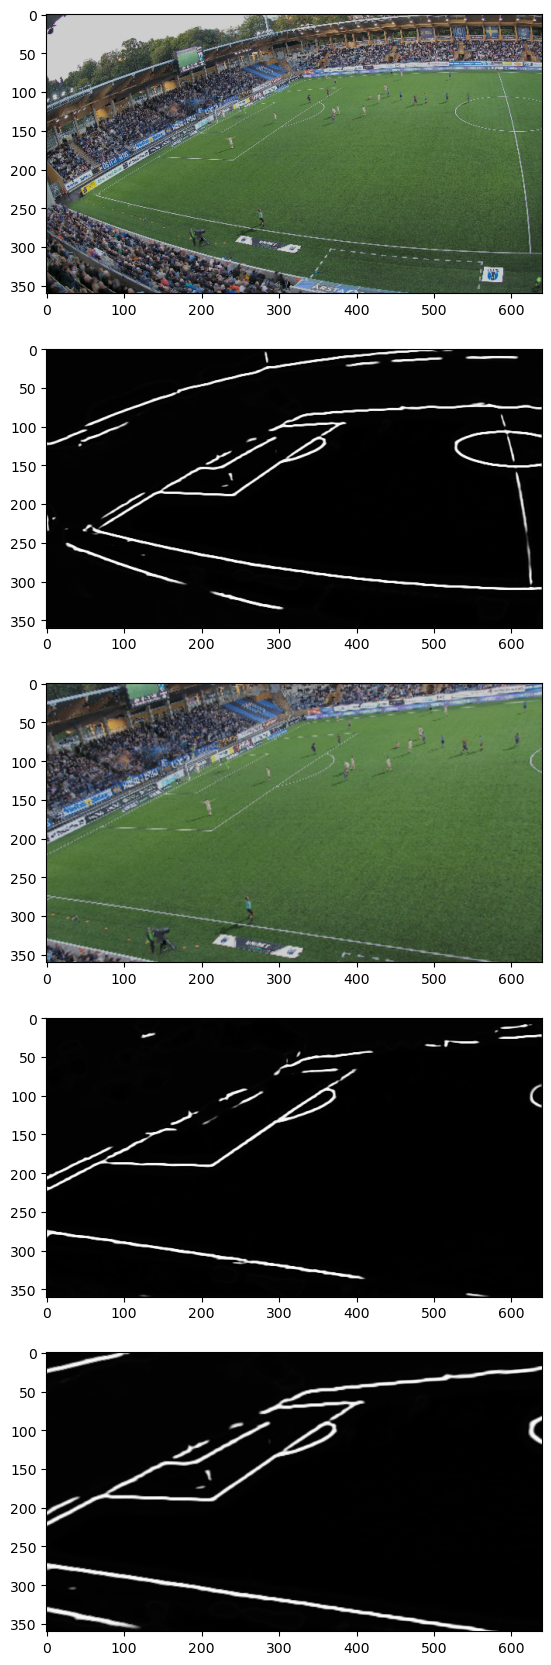

In [10]:
fig, ax = plt.subplots(nrows=5, figsize=(12, 21))
ax[0].imshow(img)
ax[1].imshow(seg_img, cmap='gray')
ax[2].imshow(undist_img)
ax[3].imshow(seg_img_2, cmap='gray')
ax[4].imshow(undist_seg_img, cmap='gray')
fig.show()

### Keypoints

In [11]:
metadata.model_dump()

{'id': 0,
 'file_name': '000000.jpg',
 'width': 3840,
 'height': 2160,
 'camera_matrix': array([[-4.69292492e-01,  8.64371300e-01,  1.80628926e-01,
         -3.16473637e+01],
        [ 3.80434364e-01,  1.33105367e-02,  9.24712121e-01,
          6.22067308e+00],
        [-7.96890318e-01, -5.02677917e-01,  3.35083097e-01,
         -4.65564346e+01]]),
 'dist_poly': array([ 3.66892964e-02, -1.81167156e-01,  2.68177211e-01,  3.68174240e-02,
        -4.07823682e-01,  2.50910759e-01, -1.18769035e-01,  7.68861055e-01,
        -7.07547879e-04]),
 'undist_poly': array([ 3.73205503e-12, -1.11320510e-11,  1.27131109e-11, -6.65507883e-12,
         1.03982794e+00, -5.04541695e-01,  2.34189317e-01,  1.30272126e+00,
         8.98241764e-04])}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


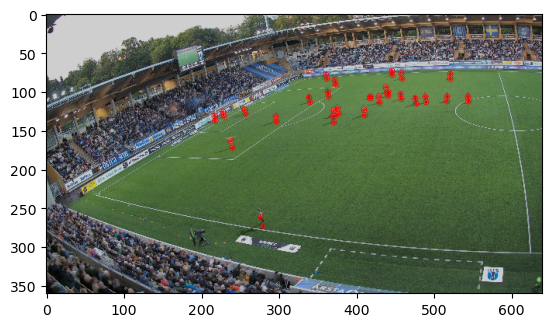

In [33]:
plt.imshow(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_66178/3177217098.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


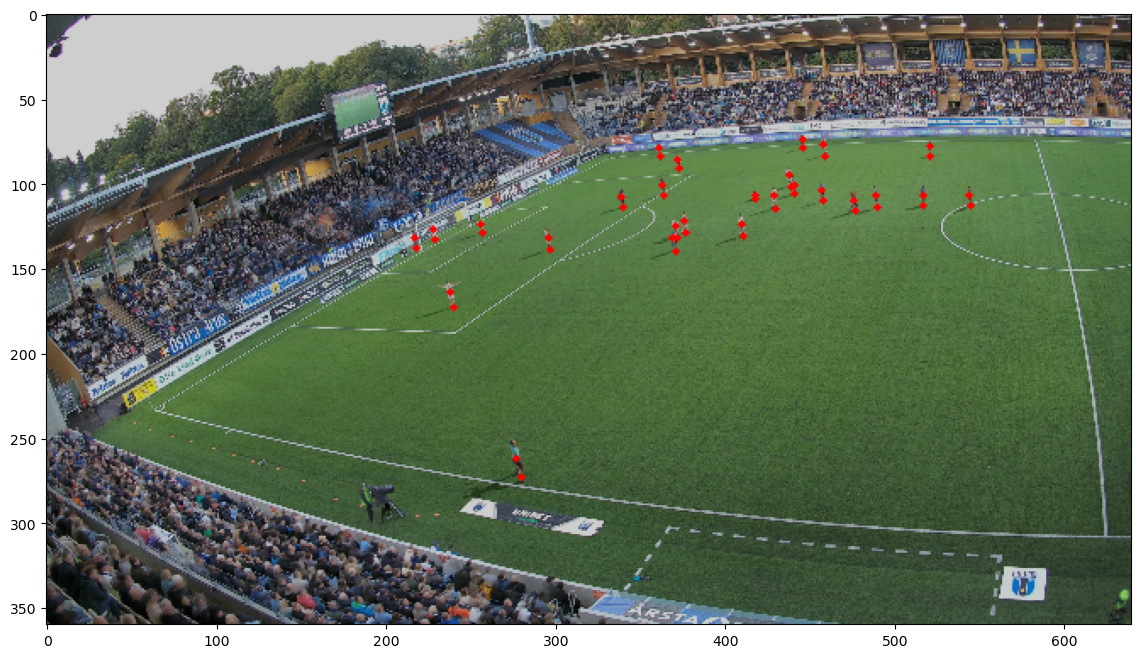

In [39]:
annotated_img = img.copy()
for annotation in annotations:
    for x, y, z in annotation.keypoints.astype('int'):
        x0, y0 = int(x / z * width / metadata.width), int(y / z * height / metadata.height)
        annotated_img = cv2.circle(annotated_img, (x0, y0), 2, (255, 0, 0), -1)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(annotated_img)
fig.show()

In [15]:
annotations[0].model_dump()

{'id': 0,
 'keypoints': array([[1.77704268e+03, 7.94416565e+02, 1.00000000e+00],
        [1.78591306e+03, 8.38012619e+02, 1.00000000e+00]]),
 'keypoints_3d': array([[-3.86380116, 37.88412386,  0.99654031,  1.        ],
        [-3.86380116, 37.88412386,  0.        ,  1.        ]]),
 'position_on_pitch': array([-3.86380116, 37.88412386]),
 'bbox': array([1764,  755,   27,   86]),
 'area': 775.0,
 'image_id': 0,
 'category_id': 1}